In [1]:
# ==========================================
# 1. Install Libraries
# ==========================================

%pip install pandas matplotlib seaborn


# ==========================================
# 2. Import Libraries
# ==========================================

import os
import json
import glob

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.


In [2]:
# ==========================================
# 3. Load JSON Dataset
# ==========================================

records = []

for file in glob.glob("data/*.json"):

    with open(file, "r", encoding="utf-8") as f:

        data = json.load(f)

        if isinstance(data, list):
            records.extend(data)

        else:
            records.append(data)


df = pd.DataFrame(records)


print("Total Records :", len(df))
print("Total Columns :", len(df.columns))


df.head()

Total Records : 930
Total Columns : 11


,timestamp,member_name,location_zone,provider,connection_type,public_ip,routing_region,is_vpn_active,os_platform,latency_ms,status
0,2026-07-15T11:54:05.801Z,Phyu Phyu Thin,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,win32,40.0,Connected
1,2026-07-15T12:02:07.155Z,Phyu Phyu Thin,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,win32,46.0,Connected
2,2026-07-15T14:32:51.401Z,Phyu Phyu Thin,Pan Ei Phyu,Mytel,Wi-Fi,45.112.47.114,Mon,False,win32,51.0,Connected
3,2026-07-15T14:41:00.255Z,Phyu Phyu Thin,Pan Ei Phyu,Offline,Offline,None,None,False,win32,NaN,Timeout
4,2026-07-15T14:48:53.127Z,Phyu Phyu Thin,Pan Ei Phyu,Mytel,Wi-Fi,45.112.47.114,Mon,False,win32,58.0,Connected


In [3]:
# ==========================================
# 4. Dataset Information
# ==========================================

print("Dataset Shape:", df.shape)

print("\nColumn Information")
df.info()

Dataset Shape: (930, 11)

Column Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        930 non-null    object 
 1   member_name      930 non-null    object 
 2   location_zone    930 non-null    object 
 3   provider         930 non-null    object 
 4   connection_type  930 non-null    object 
 5   public_ip        930 non-null    object 
 6   routing_region   930 non-null    object 
 7   is_vpn_active    930 non-null    bool   
 8   os_platform      930 non-null    object 
 9   latency_ms       893 non-null    float64
 10  status           930 non-null    object 
dtypes: bool(1), float64(1), object(9)
memory usage: 73.7+ KB


In [4]:
# ==========================================
# 5. Missing Values
# ==========================================

print("Missing Values")

df.isnull().sum()

Missing Values


timestamp           0
member_name         0
location_zone       0
provider            0
connection_type     0
public_ip           0
routing_region      0
is_vpn_active       0
os_platform         0
latency_ms         37
status              0
dtype: int64

In [5]:
# ==========================================
# 6. Data Cleaning
# ==========================================


# Remove missing latency

print("Before latency cleaning:", len(df))

df = df.dropna(subset=["latency_ms"])

print("After latency cleaning:", len(df))



# Remove duplicate records

print("\nDuplicate Records:", df.duplicated().sum())

df = df.drop_duplicates()

print("After duplicate removal:", len(df))



# Remove Offline Network Records

print("\nBefore Offline removal:", len(df))


df = df[
    (df["provider"] != "Offline") &
    (df["connection_type"] != "Offline") &
    (df["routing_region"] != "None") &
    (df["public_ip"] != "None")
]


print("After Offline removal:", len(df))


df.head()

Before latency cleaning: 930
After latency cleaning: 893

Duplicate Records: 3
After duplicate removal: 890

Before Offline removal: 890
After Offline removal: 875


,timestamp,member_name,location_zone,provider,connection_type,public_ip,routing_region,is_vpn_active,os_platform,latency_ms,status
0,2026-07-15T11:54:05.801Z,Phyu Phyu Thin,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,win32,40.0,Connected
1,2026-07-15T12:02:07.155Z,Phyu Phyu Thin,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,win32,46.0,Connected
2,2026-07-15T14:32:51.401Z,Phyu Phyu Thin,Pan Ei Phyu,Mytel,Wi-Fi,45.112.47.114,Mon,False,win32,51.0,Connected
4,2026-07-15T14:48:53.127Z,Phyu Phyu Thin,Pan Ei Phyu,Mytel,Wi-Fi,45.112.47.114,Mon,False,win32,58.0,Connected
5,2026-07-15T14:56:52.600Z,Phyu Phyu Thin,Pan Ei Phyu,Mytel,Wi-Fi,45.112.47.114,Mon,False,win32,54.0,Connected


In [6]:
# ==========================================
# 7. Feature Engineering
# ==========================================


# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])


# Convert UTC to Myanmar Time
df["timestamp_mm"] = (
    df["timestamp"]
    .dt.tz_convert("Asia/Yangon")
)


# Extract Myanmar Time Features

df["date"] = df["timestamp_mm"].dt.date

df["hour"] = df["timestamp_mm"].dt.hour

df["weekday"] = df["timestamp_mm"].dt.day_name()



df[["timestamp", "timestamp_mm", "hour"]].head()

,timestamp,timestamp_mm,hour
0,2026-07-15 11:54:05.801000+00:00,2026-07-15 18:24:05.801000+06:30,18
1,2026-07-15 12:02:07.155000+00:00,2026-07-15 18:32:07.155000+06:30,18
2,2026-07-15 14:32:51.401000+00:00,2026-07-15 21:02:51.401000+06:30,21
4,2026-07-15 14:48:53.127000+00:00,2026-07-15 21:18:53.127000+06:30,21
5,2026-07-15 14:56:52.600000+00:00,2026-07-15 21:26:52.600000+06:30,21


In [7]:
# ==========================================
# 8. Numerical Statistics
# ==========================================

df.describe()

,latency_ms,hour
count,875.000000,875.000000
mean,161.098971,13.057143
std,343.219373,8.285049
min,39.000000,0.000000
25%,53.000000,5.000000
50%,57.000000,13.000000
75%,101.000000,21.000000
max,3670.000000,23.000000


In [ ]:
# ==========================================
# 9. Category Analysis
# ==========================================


print("ISP Providers")
display(df["provider"].value_counts())


print("\nConnection Type")
display(df[""].value_counts())


print("\nOperating connection_typeSystem")
display(df["os_platform"].value_counts())


print("\nRouting Region")
display(df["routing_region"].value_counts())


print("\nLocation Zone")
display(df["location_zone"].value_counts())


print("\nVPN Status")
display(df["is_vpn_active"].value_counts())

ISP Providers


provider
Mytel    875
Name: count, dtype: int64


Connection Type


connection_type
Wi-Fi    875
Name: count, dtype: int64


Operating System


...

routing_region
Mon State        332
Mon              211
Bago Region      205
Yangon Region     89
Yangon            38
Name: count, dtype: int64


Location Zone


location_zone
Pan Ei Phyu        516
Mingalar Garden    336
CU                  18
Final Section B      5
Name: count, dtype: int64


VPN Status


is_vpn_active
False    875
Name: count, dtype: int64

In [9]:
# ==========================================
# 10. Final ISP Analysis Dataset
# ==========================================


isp_df = df.copy()


print("Final Analysis Records:", len(isp_df))

isp_df.head()

Final Analysis Records: 875


,timestamp,member_name,location_zone,provider,connection_type,public_ip,routing_region,is_vpn_active,os_platform,latency_ms,status,timestamp_mm,date,hour,weekday
0,2026-07-15 11:54:05.801000+00:00,Phyu Phyu Thin,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,win32,40.0,Connected,2026-07-15 18:24:05.801000+06:30,2026-07-15,18,Wednesday
1,2026-07-15 12:02:07.155000+00:00,Phyu Phyu Thin,Final Section B,Mytel,Wi-Fi,43.231.66.234,Yangon,False,win32,46.0,Connected,2026-07-15 18:32:07.155000+06:30,2026-07-15,18,Wednesday
2,2026-07-15 14:32:51.401000+00:00,Phyu Phyu Thin,Pan Ei Phyu,Mytel,Wi-Fi,45.112.47.114,Mon,False,win32,51.0,Connected,2026-07-15 21:02:51.401000+06:30,2026-07-15,21,Wednesday
4,2026-07-15 14:48:53.127000+00:00,Phyu Phyu Thin,Pan Ei Phyu,Mytel,Wi-Fi,45.112.47.114,Mon,False,win32,58.0,Connected,2026-07-15 21:18:53.127000+06:30,2026-07-15,21,Wednesday
5,2026-07-15 14:56:52.600000+00:00,Phyu Phyu Thin,Pan Ei Phyu,Mytel,Wi-Fi,45.112.47.114,Mon,False,win32,54.0,Connected,2026-07-15 21:26:52.600000+06:30,2026-07-15,21,Wednesday


1.  provider
Mytel    875
Name: count, dtype: int64


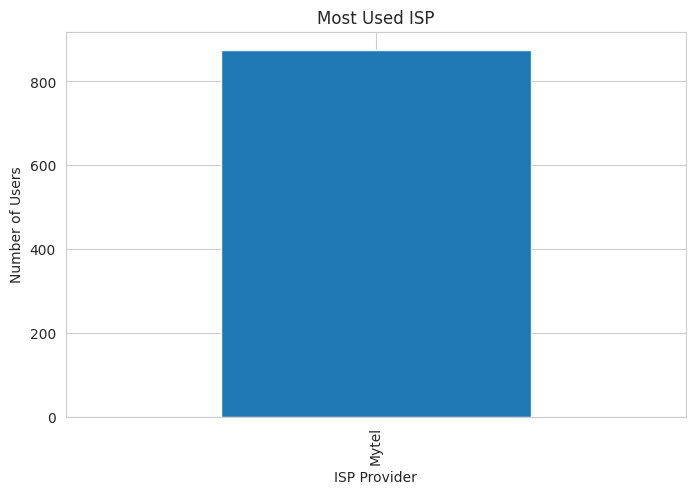

In [10]:
# ==========================================
# ISP Analysis Questions
# ==========================================
# 1. Which ISP is used the most?

isp_usage = isp_df["provider"].value_counts()

isp_usage
print("1. ", isp_usage)

plt.figure(figsize=(8,5))

isp_usage.plot(kind="bar")

plt.title("Most Used ISP")
plt.xlabel("ISP Provider")
plt.ylabel("Number of Users")

plt.show()

2. provider
Mytel    161.098971
Name: latency_ms, dtype: float64


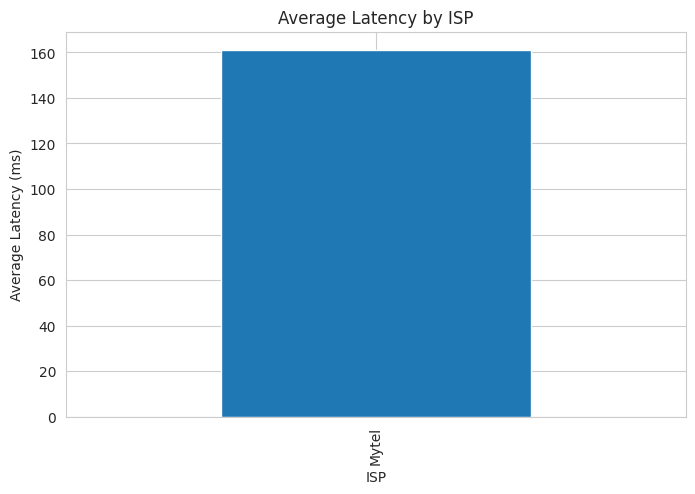

In [11]:
# 2. Which ISP has lowest average latency?

isp_latency = (
    isp_df
    .groupby("provider")["latency_ms"]
    .mean()
    .sort_values()
)

isp_latency
print("2.", isp_latency)

plt.figure(figsize=(8,5))

isp_latency.plot(kind="bar")

plt.title("Average Latency by ISP")
plt.xlabel("ISP")
plt.ylabel("Average Latency (ms)")

plt.show()

In [12]:
# 3. Which location has highest latency?

location_latency = (
    isp_df
    .groupby("location_zone")["latency_ms"]
    .mean()
    .sort_values(ascending=False)
)


location_latency

location_zone
Mingalar Garden    240.005952
CU                 129.500000
Pan Ei Phyu        111.503876
Final Section B     90.520000
Name: latency_ms, dtype: float64

In [13]:
# 4. How many users use VPN?
vpn_usage = isp_df["is_vpn_active"].value_counts()

vpn_usage

is_vpn_active
False    875
Name: count, dtype: int64

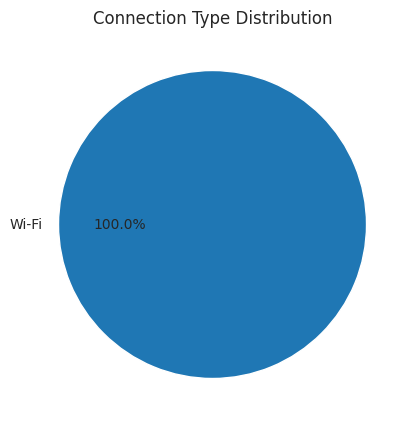

In [14]:
# 5. Wi-Fi vs Mobile Data Usage
connection_usage = isp_df["connection_type"].value_counts()

connection_usage

plt.figure(figsize=(7,5))

connection_usage.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Connection Type Distribution")

plt.ylabel("")

plt.show()

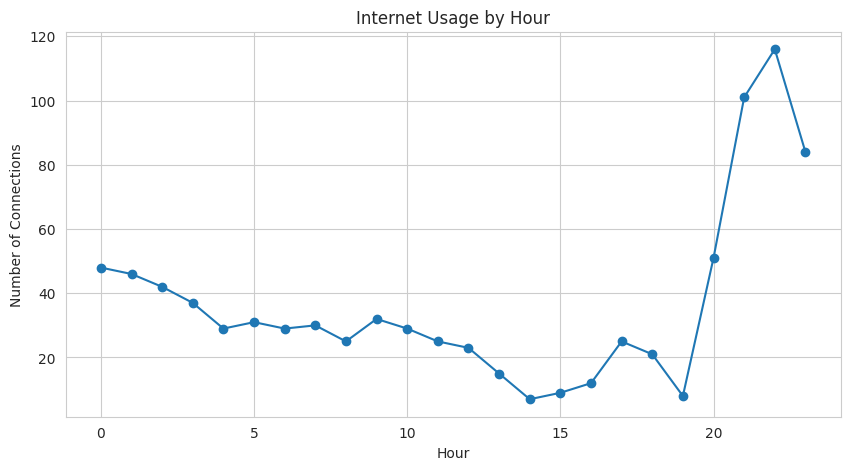

In [15]:
# 6. At what hour is internet used most?
hour_usage = (
    isp_df["hour"]
    .value_counts()
    .sort_index()
)


hour_usage
plt.figure(figsize=(10,5))

hour_usage.plot(kind="line", marker="o")


plt.title("Internet Usage by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Connections")


plt.show()

In [16]:
# 7. Most Frequent Routing Region

routing_usage = isp_df["routing_region"].value_counts()

routing_usage

routing_region
Mon State        332
Mon              211
Bago Region      205
Yangon Region     89
Yangon            38
Name: count, dtype: int64

In [17]:
# 8. Most Common OS Platform
os_usage = isp_df["os_platform"].value_counts()

os_usage

os_platform
win32    695
linux    180
Name: count, dtype: int64